<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:30px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 92 · Solutions</div>
  <div style="font-size:30px;font-weight:900;line-height:1.1;margin:10px 0 6px">Chapter 92 &#183; Solutions</div>
  <div style="font-size:14px;color:#fff7ed;max-width:740px;line-height:1.6">Five challenges, each verified in code.</div>

</div>

Solutions to the five challenges from Chapter 92. Each is worked with libraries (statsmodels, scikit-learn), not hand-rolled formulas, except where the point is to confirm the formula matches the library.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
try:
    homes = pd.read_excel('../../data/simple-linear-regression--homes.xlsx', sheet_name='Sales')
except FileNotFoundError:
    homes = pd.read_excel(BASE + 'simple-linear-regression--homes.xlsx', sheet_name='Sales')
model = ols('price ~ size_sqft', homes).fit()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 1</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Fit and read a line</div>
<div style="color:#4a5578;margin-top:5px">Report the slope, its 95% CI, and R-squared.</div>
</div>

In [3]:
slope = model.params['size_sqft']; lo, hi = model.conf_int().loc['size_sqft']
print(f'Slope: each extra sqft adds ${slope:,.0f} to price (95% CI ${lo:,.0f} to ${hi:,.0f}).')
print(f'R-squared: size explains {model.rsquared*100:.0f}% of the variation in price.')

Slope: each extra sqft adds $180 to price (95% CI $175 to $185).
R-squared: size explains 96% of the variation in price.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 2</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Confidence vs prediction interval</div>
<div style="color:#4a5578;margin-top:5px">Both intervals at 2,000 sqft, and why one is wider.</div>
</div>

In [4]:
p = model.get_prediction(pd.DataFrame({'size_sqft':[2000]})).summary_frame().iloc[0]
print(f"confidence (mean): ${p['mean_ci_lower']:,.0f} to ${p['mean_ci_upper']:,.0f}")
print(f"prediction (one) : ${p['obs_ci_lower']:,.0f} to ${p['obs_ci_upper']:,.0f}")
print('The prediction interval is wider because a single home carries the residual scatter on top of the uncertainty in the mean line.')

confidence (mean): $412,111 to $420,496
prediction (one) : $361,929 to $470,678
The prediction interval is wider because a single home carries the residual scatter on top of the uncertainty in the mean line.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 3</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Diagnose the conditions</div>
<div style="color:#4a5578;margin-top:5px">Residual-vs-fitted, Q-Q, Breusch-Pagan, Durbin-Watson.</div>
</div>

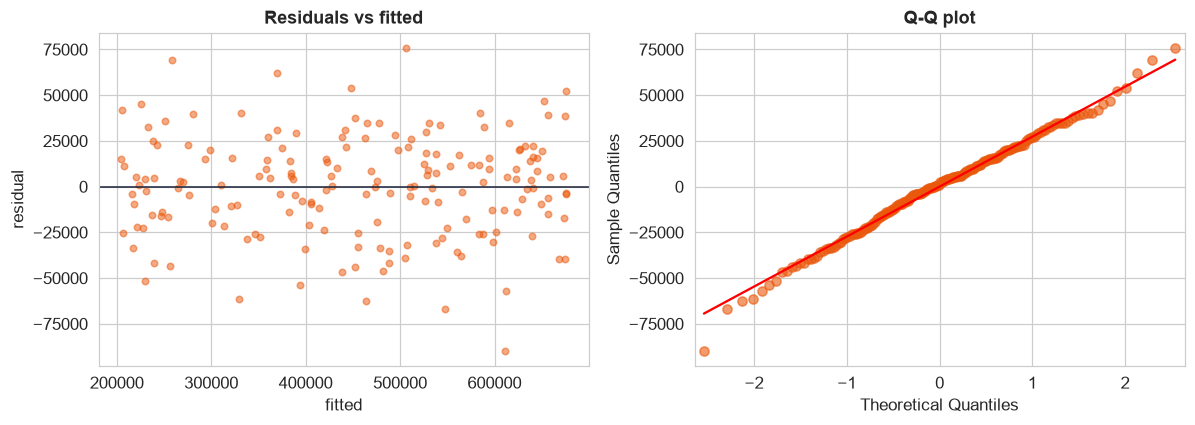

Breusch-Pagan p = 0.81 (equal variance)
Durbin-Watson   = 2.22 (independence)
No pattern, straight Q-Q, p>0.05, DW near 2 -> LINE holds.


In [5]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].scatter(model.fittedvalues, model.resid, s=18, color=ORG, alpha=0.5); ax[0].axhline(0,color=INK,lw=1)
ax[0].set(title='Residuals vs fitted', xlabel='fitted', ylabel='residual')
sm.qqplot(model.resid, line='s', ax=ax[1], markerfacecolor=ORG, markeredgecolor=ORG, alpha=0.6); ax[1].set_title('Q-Q plot')
plt.tight_layout(); plt.show()
print(f"Breusch-Pagan p = {het_breuschpagan(model.resid, model.model.exog)[1]:.2f} (equal variance)")
print(f"Durbin-Watson   = {durbin_watson(model.resid):.2f} (independence)")
print('No pattern, straight Q-Q, p>0.05, DW near 2 -> LINE holds.')

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 4</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Break it, then fix it</div>
<div style="color:#4a5578;margin-top:5px">Fit exp-growth data raw, show the funnel, refit on log(y).</div>
</div>

raw   Breusch-Pagan p = 0.0000 (violated)
log   Breusch-Pagan p = 0.01 (fixed)


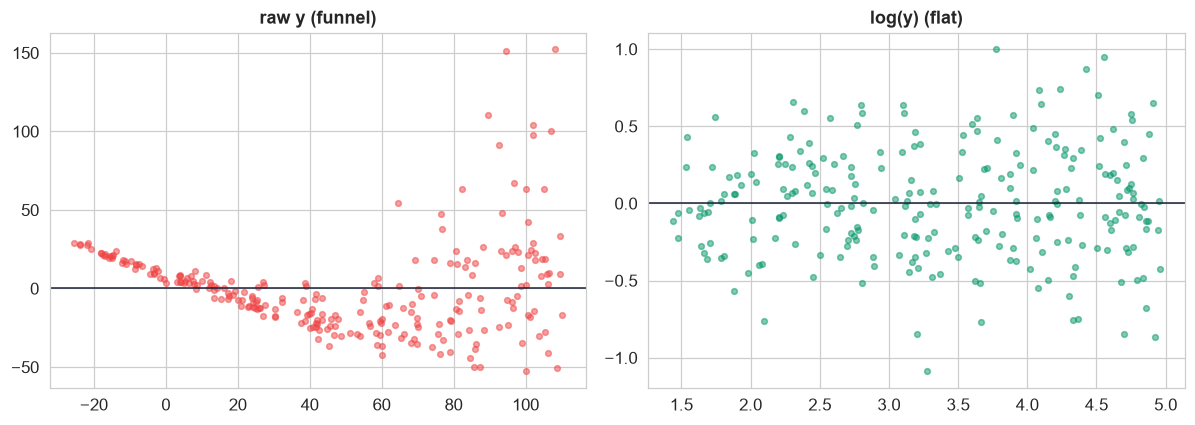

In [6]:
rng = np.random.default_rng(4); x = rng.uniform(1,10,250)
y = np.exp(1.0 + 0.4*x + rng.normal(0,0.35,250))
d = pd.DataFrame({'x':x,'y':y}); d['logy']=np.log(d['y'])
from statsmodels.stats.diagnostic import het_breuschpagan
m0 = ols('y ~ x', d).fit(); m1 = ols('logy ~ x', d).fit()
print(f"raw   Breusch-Pagan p = {het_breuschpagan(m0.resid,m0.model.exog)[1]:.4f} (violated)")
print(f"log   Breusch-Pagan p = {het_breuschpagan(m1.resid,m1.model.exog)[1]:.2f} (fixed)")
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].scatter(m0.fittedvalues, m0.resid, s=14, color=RED, alpha=0.5); ax[0].axhline(0,color=INK,lw=1); ax[0].set_title('raw y (funnel)')
ax[1].scatter(m1.fittedvalues, m1.resid, s=14, color=GREEN, alpha=0.5); ax[1].axhline(0,color=INK,lw=1); ax[1].set_title('log(y) (flat)')
plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 5</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Least squares by hand, then by library</div>
<div style="color:#4a5578;margin-top:5px">Confirm b1 = r&#183;(sy/sx) and b0 = ybar &#8722; b1&#183;xbar match statsmodels.</div>
</div>

In [7]:
x = homes['size_sqft']; y = homes['price']
r = np.corrcoef(x, y)[0,1]
b1 = r * y.std(ddof=1)/x.std(ddof=1)
b0 = y.mean() - b1*x.mean()
print(f'by hand : b1 = {b1:,.3f}   b0 = {b0:,.1f}')
print(f'library : b1 = {model.params["size_sqft"]:,.3f}   b0 = {model.params["Intercept"]:,.1f}')
print('They match: the slope is the correlation rescaled by the ratio of standard deviations.')

by hand : b1 = 180.131   b0 = 56,040.8
library : b1 = 180.131   b0 = 56,040.8
They match: the slope is the correlation rescaled by the ratio of standard deviations.


---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>